In [17]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

Cargo los datos inmobiliarios

In [18]:
df_inm = pd.read_csv("C:/Users/Ariela/Desktop/EDA - Inmobiliario/Inmobiliario/src/data/EDA_Inmob_Lascondes.csv")

In [19]:
df_inm.head(5)

,titulo,precio,dormitorios,baños,m2,codigo,estacionamientos,fecha
0,San Olav 6150,$ 645.000,1,1.0,40 m²,111934266,1,05/04/2026
1,La Gioconda,$ 1.753.036,4,4.0,160 m²,112657491,1,30/03/2026
2,San Carlos de Apoquindo 2201,$ 2.191.295,3,3.0,127 m²,113875739,2,28/03/2026
3,Acogedor dpto. Amoblado en las condes a pasos ...,$ 996.043,1,1.0,51 m²,89888095,1,02/08/2025
4,Carol Urzúa / Apoquindo,$ 836.676,1,1.0,"46,9 m²",114722166,1,06/04/2026


In [20]:
df_inm.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titulo            265 non-null    str    
 1   precio            265 non-null    str    
 2   dormitorios       265 non-null    int64  
 3   baños             263 non-null    float64
 4   m2                259 non-null    str    
 5   codigo            265 non-null    int64  
 6   estacionamientos  265 non-null    int64  
 7   fecha             265 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 16.7 KB


In [21]:
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())  #Voy a corregir la columna de precio, porque piensa que es un str. Elimino el signo $ y los puntos

In [22]:
df_inm['m2'] = pd.to_numeric(df_inm['m2'].str.replace(" m²", "", regex=False).str.replace(",", ".", regex=False))

In [23]:
df_inm['precio_eu'] = df_inm['precio']*0.00094

# Elimino ouliers
p95 = df_inm["precio_eu"].quantile(0.95)
p05 = df_inm["precio_eu"].quantile(0.05)

df_inm = df_inm[(df_inm["precio_eu"] > p05) & (df_inm["precio_eu"] < p95)]

#Limpio los datos que no existen
df_inm = df_inm.dropna()


df_inm['precioeu_m2'] = df_inm['precio_eu']/df_inm['m2']

df_inm.describe()


,precio,dormitorios,baños,m2,codigo,estacionamientos,precio_eu,precioeu_m2
count,2.320000e+02,232.000000,232.000000,232.000000,2.320000e+02,232.000000,232.000000,232.000000
mean,1.749530e+06,2.465517,2.293103,110.349655,1.021491e+08,1.176724,1644.558577,31.586399
std,7.172971e+05,1.072530,0.993636,70.831159,2.096420e+07,1.514367,674.259319,129.962889
min,7.012140e+05,1.000000,1.000000,1.000000,9.973685e+06,0.000000,659.141160,5.253677
25%,1.200000e+06,2.000000,2.000000,65.750000,9.774113e+07,0.000000,1128.000000,12.214405
50%,1.633511e+06,2.000000,2.000000,94.000000,1.108320e+08,1.000000,1535.500340,15.030208
75%,2.191295e+06,3.000000,3.000000,140.000000,1.133803e+08,1.250000,2059.817300,20.618630
max,4.302906e+06,6.000000,6.000000,499.000000,1.147222e+08,14.000000,4044.731640,1745.816880


(2,)


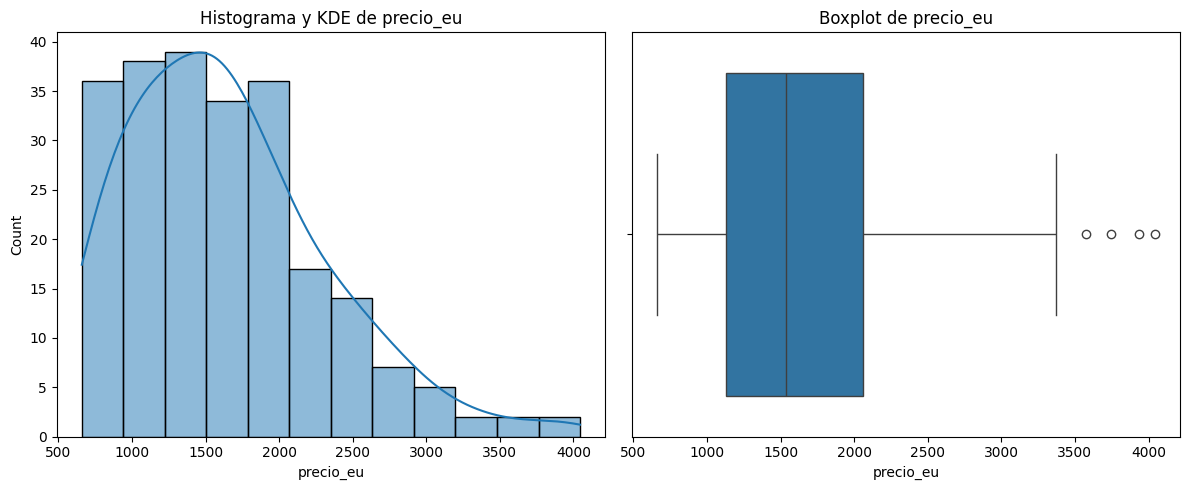

In [24]:
plot_combined_graphs(df_inm,["precio_eu"])

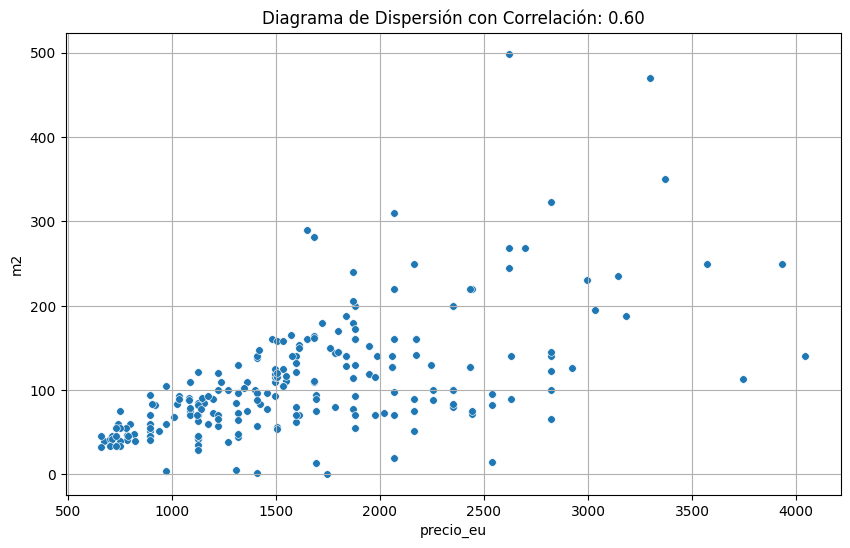

In [25]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precio_eu","m2", mostrar_correlacion= True, tamano_puntos= 30)

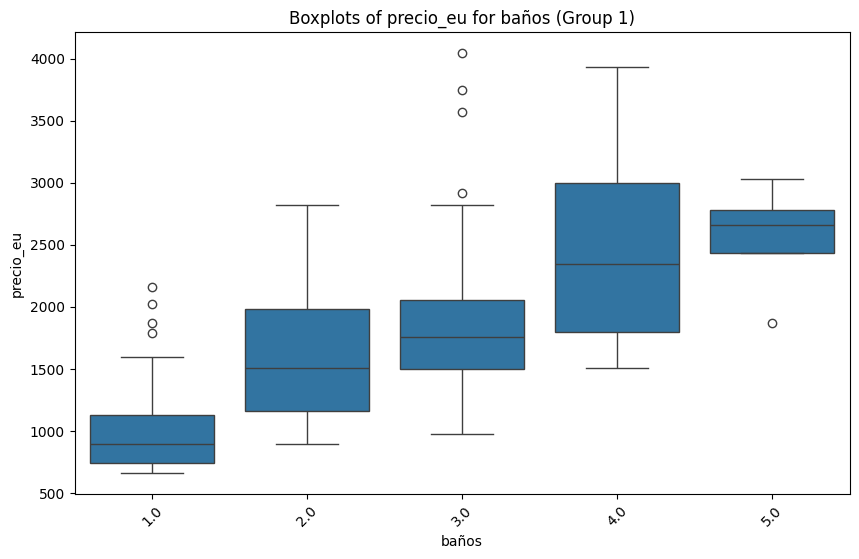

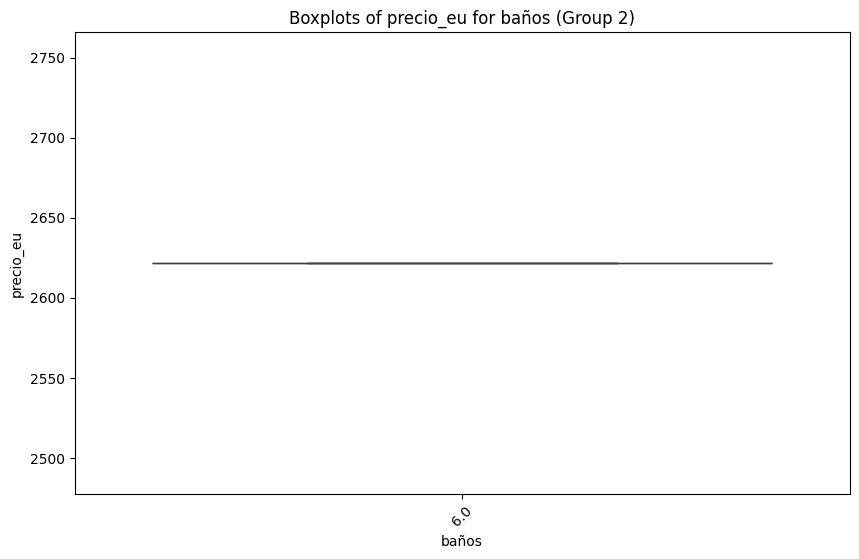

In [26]:
plot_grouped_boxplots(df_inm, "baños","precio_eu")

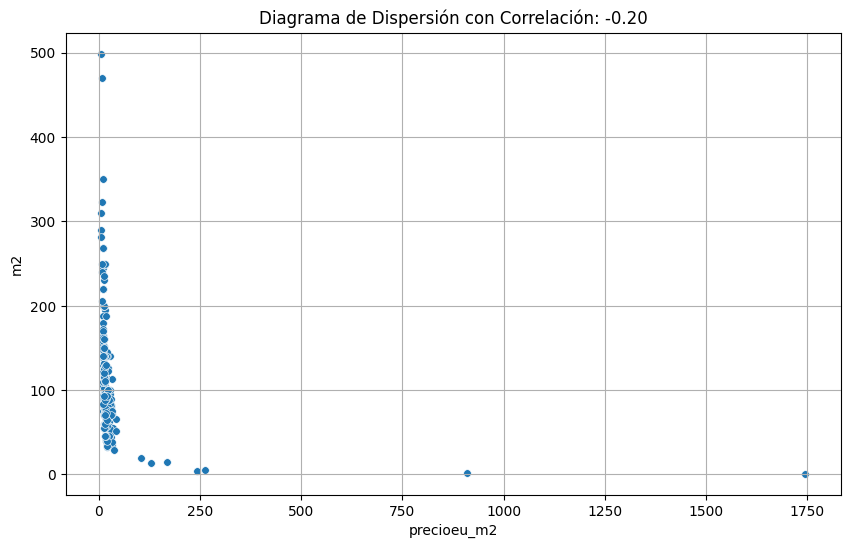

In [27]:
# Análisis bivariante

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

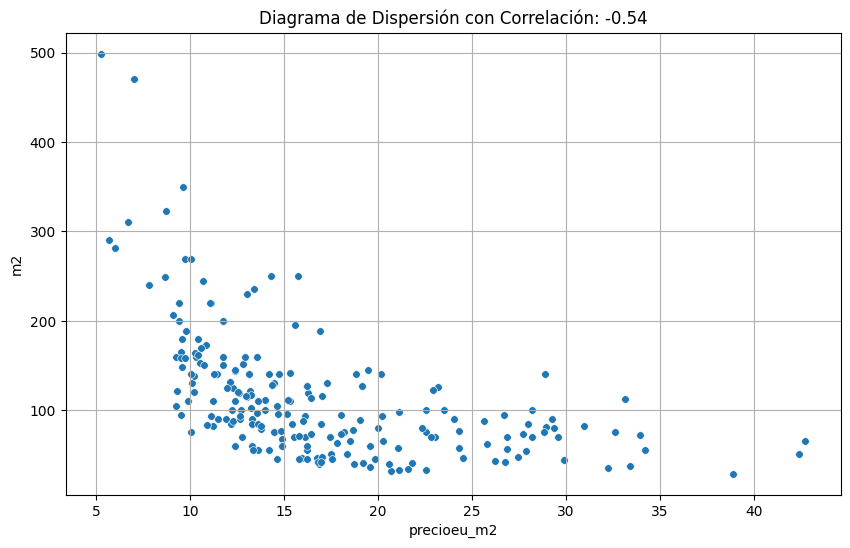

In [30]:
# Análisis bivariante - elimino otros valores extremos

filtro = (df_inm.precioeu_m2 < 100)
df_inm = df_inm[filtro]

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

In [29]:
# Análisis por grupo

rangos = [0, 40, 60, 80, 100, 120 , float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100', '100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()

,count,mean,std,min,25%,50%,75%,max
grupo_m2,,,,,,,,
<40,15.0,60.827577,69.167441,16.853048,20.639086,22.569028,71.148276,243.432975
40-60,37.0,20.239364,6.549693,12.376667,15.939130,17.546667,24.521739,42.392157
60-80,34.0,21.426643,7.186752,10.026667,15.881130,19.327244,26.586580,42.727273
80-100,40.0,17.464627,6.280761,9.500000,12.546829,14.932292,22.795000,30.951220
100-120,23.0,14.185172,4.594813,9.273637,12.533333,13.218077,14.903368,33.142670
>120,80.0,12.447147,4.061048,5.253677,9.757332,11.750000,14.205470,28.890940
